In [1]:
!!pip install -q git+https://github.com/keras-team/keras-hub.git
!!pip install -q --upgrade keras

[]

In [2]:
import os
import json
import math
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import losses
from keras import ops
from keras import optimizers
from keras.optimizers import schedules
from keras import metrics
from keras.applications.imagenet_utils import decode_predictions
import keras_hub

import tensorflow as tf
import tensorflow_datasets as tfds

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/co

In [3]:
from tensorflow import keras
from keras.layers import Dropout, Dense, GlobalAveragePooling1D, Flatten
import keras_hub
from keras import layers
from keras.layers import Lambda
import pandas as pd
keras.utils.set_random_seed(42)

In [4]:
!wget -q -P ./ https://www.dropbox.com/s/w07liww46kgxo1m/handbags-shoes.zip
!unzip -qq handbags-shoes.zip

In [5]:
import os, shutil, pathlib
base_dir = pathlib.Path("/content/handbags-shoes")

In [6]:
for category in ('handbags', 'shoes'):
  fnames = os.listdir(base_dir/category)

  dir = base_dir /'train' / category
  os.makedirs(dir)
  for fname in fnames[:50]:  # the first 50 examples go into the training set
    shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)

  dir = base_dir /'validation' / category
  os.makedirs(dir)
  for fname in fnames[50:75]:  # the next 25 examples go into the validation set
    shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)

  dir = base_dir /'test' / category
  os.makedirs(dir)
  for fname in fnames[75:]:  # the remaining examples go into the test set
    shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)

In [7]:
train_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'train',
    image_size=(224,224),
    batch_size=32)

validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'validation',
    image_size=(224,224),
    batch_size=32)

test_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'test',
    image_size=(224,224),
    batch_size=32)

Found 97 files belonging to 2 classes.
Found 48 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [8]:
for images, _ in train_dataset.take(1):
  print(images[0].shape)

(224, 224, 3)


In [9]:
# Numer of Classes
num_classes = 2 # Adjust to the numer of classes in your dataset

# Preprocessing function for both images and labels
def preprocess_data(image, label):
  label = tf.cast(label, tf.int32)
  label = tf.one_hot(label, num_classes) #Convert labels to one-hot
  return image, label

train_dataset = train_dataset.map(preprocess_data)
validation_dataset = validation_dataset.map(preprocess_data)
test_dataset = test_dataset.map(preprocess_data)

# Debug to check shapes
for images, labels in train_dataset.take(1):
  print("Image shape:", images.shape) #should be (32, 224, 224, 3)
  print("Label shape:", labels.shape) #should be (32, num_classes)

Image shape: (32, 224, 224, 3)
Label shape: (32, 2)


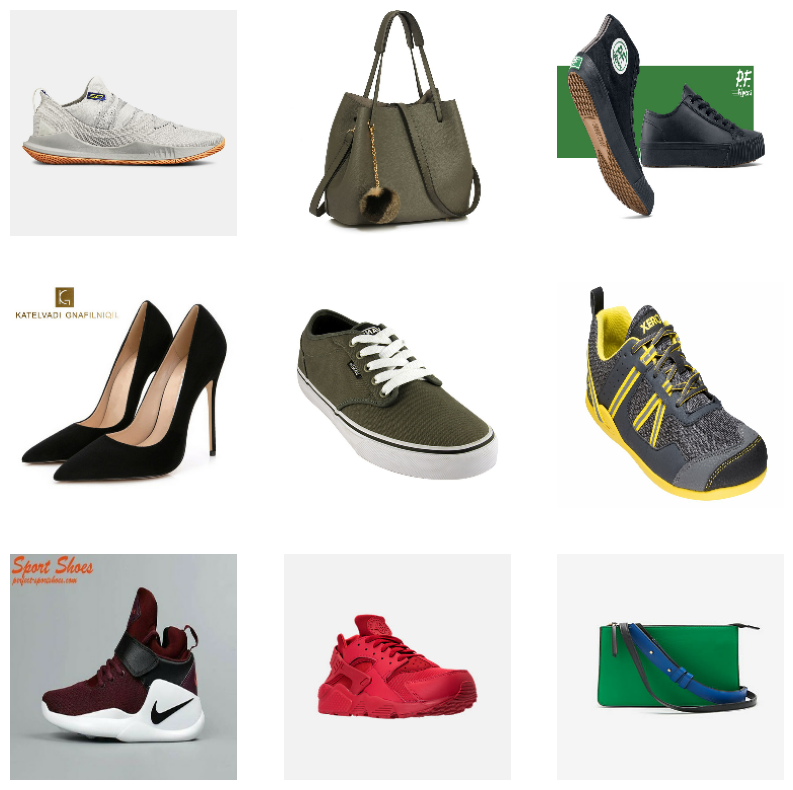

In [10]:
plt.figure(figsize=(10,10))
for images, _ in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")

In [11]:
patch_size = 16
image_size = 224

In [12]:
def get_patches(images, patch_size=16):
  input_shape = tf.shape(images) # Changed keras.ops.shape to tf.shape
  batch_size = input_shape[0]
  height = input_shape[1]
  width = input_shape[2]
  channels = input_shape[3]
  num_patches_h = height // patch_size
  num_patches_w = width // patch_size
  # key utility taht breaks up an image into patches.
  # Return batch_size x patch_index_i x patch_index_j x vectorized_patch_dimension
  patches = tf.image.extract_patches(images=images, # Added images = for clarity
                                     sizes=[1, patch_size, patch_size, 1],
                                     strides=[1, patch_size, patch_size, 1],
                                     rates=[1,1,1,1],
                                     padding='VALID')
  # using tf.reshape for consistancy with other Tensorflow operations
  # Cast patches to float32 to ensure compatibility
  patches = tf.reshape(tf.cast(patches, dtype=tf.float32), # Cast patches to floaot32
                       (
                           batch_size,
                           num_patches_h * num_patches_w,
                           patch_size *patch_size * channels,
                       ),
                       )
  return patches

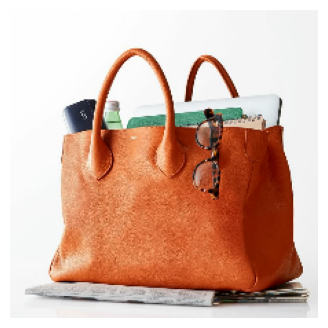

In [13]:
for images, _ in train_dataset.take(1):
  plt.figure(figsize=(4,4))
  resized_image = keras.ops.image.resize(
      keras.ops.convert_to_tensor([images[0]]), size=(image_size, image_size)
  )
  no_channels = keras.ops.shape(resized_image)[-1]

  plt.imshow(images[0].numpy().astype("uint8"))
  plt.axis("off")

Image size: 224 X 224
Patch size: 16 X 16
Patches per image: 196
Elements per image: 768


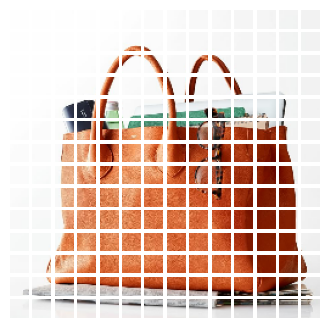

In [14]:
patches = get_patches(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per image: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4,4))
for i, patch in enumerate(patches[0]):
  ax = plt.subplot(n,n, i+1)
  patch_img = keras.ops.reshape(patch.numpy(),(16,16, no_channels))
  plt.imshow(keras.ops.convert_to_numpy(patch_img).astype("uint8"))
  plt.axis("off")

In [15]:
#Recall num_patches is akin to the length of our context window
num_patches = (image_size //patch_size) ** 2

# Transformer dimensions
projection_dim = 64
num_heads = 8
transformer_units = [
    projection_dim * 2,
    projection_dim,
] #no. units in the feedforward portion of the transformers
num_transformer_layers = 2

# Classification head dimentions
mlp_head_units = [
    512,
    256,
]

num_classes = 2
input_shape = (image_size, image_size, 3)

In [16]:
inputs = keras.Input(shape=input_shape)

# Define Data augmentation pipeline
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1,0.1),
])
x = data_augmentation(inputs)

# Create patches
patches = Lambda(get_patches, output_shape=(num_patches, patch_size * patch_size *3))(x)

# Encode patches by projecting and then adding a position embeddding
projection = layers.Dense(units=projection_dim)
position_embedding = layers.Embedding(
    input_dim=num_patches, output_dim=projection_dim
)
encoded_patches = projection(patches) + position_embedding(keras.ops.expand_dims(keras.ops.arange(start=0, stop=num_patches, step=1),axis=0))

#  Create multiple layers of the transformer block
for _ in range(num_transformer_layers):
  # Layer normalization 1
  x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
  # create multi-heat attention layer
  attention_output = layers.MultiHeadAttention(
      num_heads=num_heads, key_dim=projection_dim,dropout=0.1
  )(x1,x1)
  # Skip connection 1
  x2 = layers.Add()([attention_output, encoded_patches])
  # Layer normalization 2
  x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
  # MLP
  for units in transformer_units:
    x3 = layers.Dense(units, activation=keras.activations.gelu)(x3)
    x3 = layers.Dropout(0.5)(x3)
# Create a [batch_siz, projection_dim] tensor

representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.Flatten()(representation)
representation = layers.Dropout(0.5)(representation)

# Add MLP
for units in mlp_head_units:
  representation = layers.Dense(units, activation=keras.activations.gelu)(representation)
  representation = layers.Dropout(0.5)(representation)

# Classify output
logits = layers.Dense(num_classes)(representation)

# Create teh keras model
model = keras.Model(inputs=inputs, outputs=logits)

In [17]:
optimizer = keras.optimizers.AdamW(
    learning_rate = 0.001
)

model.compile(
  optimizer=optimizer,
  loss=keras.losses.CategoricalCrossentropy(from_logits=True),
  metrics=[
      keras.metrics.CategoricalAccuracy(name="accuracy"),
  ],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 196, 768)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 196, 64)        │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 196, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 196, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,604,226 (25.19 MB)

 Trainable params: 6,604,226 (25.19 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# before calling fit, build the model with sample input:
sample_input = tf.zeros((32, image_size, image_size, 3))
model(sample_input)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=40,
    batch_size=32
)

Epoch 1/40


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 491ms/step - accuracy: 0.4433 - loss: 9.7590 - val_accuracy: 0.5000 - val_loss: 4.8308
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 0.5155 - loss: 4.1374 - val_accuracy: 0.5000 - val_loss: 4.8466
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.5464 - loss: 5.9723 - val_accuracy: 0.5000 - val_loss: 7.3447
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.4742 - loss: 6.1953 - val_accuracy: 0.5000 - val_loss: 8.9805
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.4948 - loss: 6.4366 - val_accuracy: 0.5000 - val_loss: 4.0198
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step - accuracy: 0.4742 - loss: 8.2868 - val_accuracy: 0.5000 - val_loss: 4.4466
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step - accuracy: 0.4227 - loss: 7.6788 - val_accuracy: 0.5000 - val_loss: 3.7050
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - accuracy: 0.4742 - loss: 7.0609 - val_accuracy: 0.5000 - val_loss: 1.3958
Ep

In [22]:
# Load the ViT backbone and preprocessor
backbone = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet")
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

# Define data augmentation pipeline
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1,0.1),
])

# Create the custom model
input = keras.Input(shape=(224,224, 3)) #input shape for the images
x = data_augmentation(inputs) #apply data augmentation]
x = preprocessor(x) #preprocess inputs for ViT
x = backbone(x) #pass through the vit backbone
x = Flatten()(x) #flatten the output layer
x = Dense(backbone.hidden_dim, activation='linear')(x) #project down to the hidden dimention
x = Dropout(0.5)(x) #add dropout for regularization
x = Dense(256, activation='relu')(x) # add dense layer for feature learnign
x = Dropout(0.5)(x) #add another droput layer
outputs = Dense(2, activation="softmax")(x)#final classification layer

# create model
model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_image_classifier_preproce… │ (None, 224, 224, 3)    │             0 │
│ (ViTImageClassifierPreprocesso… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 151296)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 768)            │   116,196,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,192,130 (771.30 MB)

 Trainable params: 202,192,130 (771.30 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Freeze the backbone initially
backbone.trainable = False

# compile the model for initial training
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Train only the calssification head
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=2,
    batch_size=32
)

Epoch 1/2


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8763 - loss: 0.3805 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 756ms/step - accuracy: 0.9897 - loss: 0.0267 - val_accuracy: 1.0000 - val_loss: 3.7501e-07


In [25]:
model.evaluate(test_dataset)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.9750 - loss: 0.3091


[0.30906039476394653, 0.9750000238418579]